# Open Field Test — NWB Data Access Demo

**Dataset:** Meletis Lab, Karolinska Institutet  
**Publication:** [Mantas et al. (2024) — bioRxiv](https://doi.org/10.1101/2024.12.22.629963)

This notebook demonstrates two example sessions from the Open Field Test (OFT) dataset:

- **Example 1 — VAME behavioral motifs:** An Anxa1-Flp mouse (Tetanus toxin model) with pose
  estimation and both VAME motif labellings (157-dim and 36-dim models, 47 k-means clusters each).
- **Example 2 — Fiber photometry + kinematics:** A WT mouse from the `oft_fp`
  sub-experiment with simultaneous dLight1.3b fiber photometry (dCP) and derived kinematics.

## About the experiment

Mice explored a 40×40 cm arena with a transparent floor, recorded from below at 30 fps.
The OFT was used to study locomotion and behavioral motifs in mouse models of Parkinson's disease.
Seven sub-experiments were conducted across multiple dopamine-related genetic and lesion models
(6-OHDA, Anxa1-TetTox, MitoPark, anti-Anxa1 antibody).

## Data streams per NWB file

| Stream | NWB location | Rate | Description |
|--------|-------------|------|-------------|
| **Video** | `acquisition/Video {name}` | 30 fps | External reference to MP4 file (not embedded) |
| **Pose estimation** | `processing/behavior/PoseEstimationDeepLabCut` | 30 Hz | DeepLabCut output — 6 keypoints (x, y, confidence) |
| **VAME motifs** | `processing/behavior/VAMEProject{157,36}` | 30 Hz | `VAMEProject` container holding a `MotifSeries` of integer k-means labels per frame |
| **Fiber photometry** | `processing/ophys/FiberPhotometrySeriesDfOverF` | ~60 Hz | Processed dF/F signal (470 nm signal minus 405 nm isosbestic reference) |
| **Kinematics** | `processing/behavior/Kinematics` | 30 Hz | Derived speed, acceleration, angular speed, distance metrics |

Not all streams are present in every session. Fiber photometry is only available in the
`oft_fp` sub-experiment (31 of 161 sessions). VAME motifs are available for most sessions.
The directory names `vame_157` / `vame_36` refer to the VAME latent-space dimension used during
training; both models use **47 k-means clusters** (labels 0–46).

## Setup

In [18]:
import matplotlib.pyplot as plt
import numpy as np
from pynwb import NWBHDF5IO

%matplotlib inline
plt.rcParams["figure.figsize"] = (12, 4)
plt.rcParams["figure.dpi"] = 100

## Example 1: Behavioral motifs session

This session (sub-687643, Anxa1-Flp, Tetanus toxin / TetTox model) contains video,
pose estimation, and both VAME motif labellings (157-dim and 36-dim models).

In [19]:
nwb_path_vame = "../../../nwb_output/open_field_test/sub-687643/sub-687643_ses-oft-2023-05-16T15-31-06.nwb"

io1 = NWBHDF5IO(nwb_path_vame, mode="r")
nwbfile1 = io1.read()

print(f"Session ID:    {nwbfile1.session_id}")
print(f"Session start: {nwbfile1.session_start_time}")
print(f"Subject ID:    {nwbfile1.subject.subject_id}")
print(f"Genotype:      {nwbfile1.subject.genotype}")
print(f"Sex:           {nwbfile1.subject.sex}")
print(f"Institution:   {nwbfile1.institution}")
print(f"Lab:           {nwbfile1.lab}")

Session ID:    oft-2023-05-16T15-31-06
Session start: 2023-05-16 15:31:06+02:00
Subject ID:    687643
Genotype:      anxa1-flp
Sex:           M
Institution:   Karolinska Institutet
Lab:           Meletis


### 1.1 Video (external reference)

Videos are stored as external file references rather than embedded pixel data.
Each session has one MP4 video (H.264, 30 fps, ~856×818 pixels) recorded from below
through a transparent floor.

In [20]:
video_key = next(k for k in nwbfile1.acquisition if k.startswith("Video"))
video = nwbfile1.acquisition[video_key]
print(f"Video name:    {video.name}")
print(f"External file: {video.external_file[0]}")
print(f"Starting time: {video.starting_time} s")
print(f"Rate:          {video.rate} fps")

Video name:    Video oft_2023-05-16T15_31_06
External file: /Volumes/T9/data/Meletis/oft/videos/oft_2023-05-16T15_31_06.mp4
Starting time: 0.0 s
Rate:          30.0 fps


### 1.2 Pose estimation (DeepLabCut)

Pose estimation was performed using DeepLabCut, tracking 6 keypoints on each mouse:
**snout**, **left front paw**, **right front paw**, **left back paw**, **right back paw**,
and **tail base**. Stored via the [ndx-pose](https://github.com/rly/ndx-pose) extension.

Each keypoint has:
- `data` — (N, 2) array of (x, y) pixel coordinates at 30 Hz
- `confidence` — (N,) array of DLC likelihood scores per frame

In [21]:
behavior1 = nwbfile1.processing["behavior"]
pose = behavior1["PoseEstimationDeepLabCut"]

keypoint_names = [k.replace("PoseEstimationSeries", "") for k in pose.pose_estimation_series]
print(f"Keypoints ({len(keypoint_names)}): {keypoint_names}")
print(f"Scorer: {pose.scorer}")
print(f"Source software: {pose.source_software}")

snout = pose.pose_estimation_series["PoseEstimationSeriesSnout"]
print(f"\nSnout data shape: {snout.data.shape}  (frames × [x, y])")
print(f"Confidence shape: {snout.confidence.shape}")
print(f"Number of frames: {snout.data.shape[0]}")

Keypoints (6): ['Leftbackpaw', 'Leftfrontpaw', 'Rightbackpaw', 'Rightfrontpaw', 'Snout', 'Tailbase']
Scorer: DLC_resnet50_oft_roomIVASep13shuffle1_950000
Source software: DeepLabCut

Snout data shape: (9000, 2)  (frames × [x, y])
Confidence shape: (9000,)
Number of frames: 9000


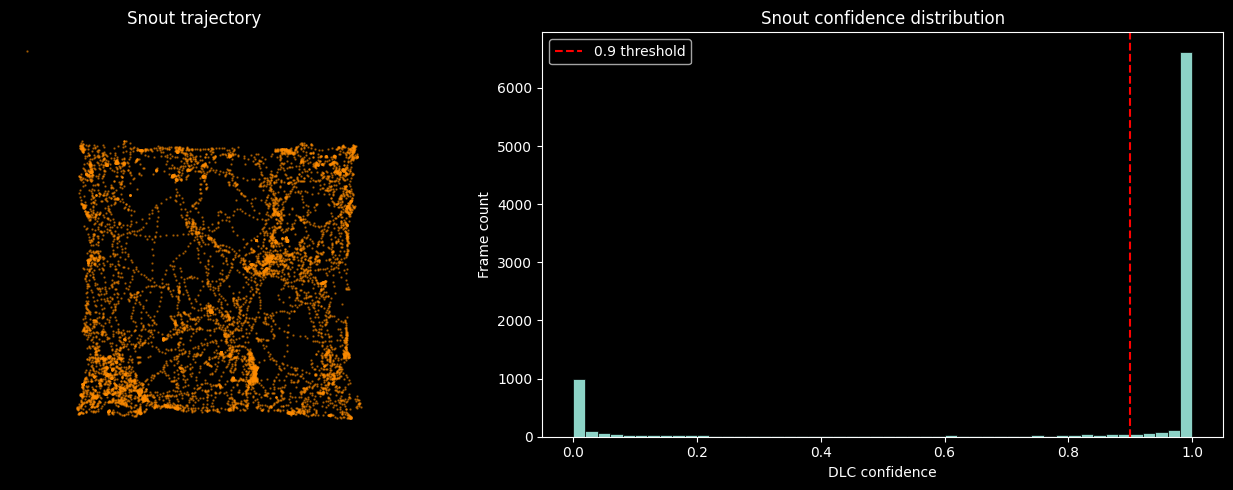

In [22]:
snout_xy = snout.data[:]
confidence = snout.confidence[:]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
time_s = np.arange(len(snout_xy)) / 30.0
sc = ax.scatter(snout_xy[:, 0], snout_xy[:, 1], c="darkorange", s=0.5,alpha=0.5)
ax.set_xlabel("x (pixels)")
ax.set_ylabel("y (pixels)")
ax.set_title("Snout trajectory")
ax.set_aspect("equal")
ax.axis("off")
ax.invert_yaxis()

ax = axes[1]
ax.hist(confidence, bins=50, edgecolor="black", linewidth=0.5)
ax.set_xlabel("DLC confidence")
ax.set_ylabel("Frame count")
ax.set_title("Snout confidence distribution")
ax.axvline(0.9, color="red", linestyle="--", label="0.9 threshold")
ax.legend()

plt.tight_layout()
plt.show()

### 1.3 VAME behavioral motifs

[VAME](https://github.com/EthoML/VAME) (Variational Animal Motion Embedding) was applied for
unsupervised behavioral classification. Each frame is assigned an integer motif label via k-means
clustering of the VAME latent space. Two VAME models were applied:

- **157-dim model** (`VAMEProject157`) — latent dimension 157, 47 k-means clusters
- **36-dim model** (`VAMEProject36`) — latent dimension 36, 47 k-means clusters

Both are stored in `processing/behavior/`. Access labels via `project.motif_series.data[:]`.

VAMEProject157:
  MotifSeries name:       VAMEMotifs157
  Shape:                  (8970,)  (299.0 s at 30.0 Hz)
  Unique motifs:          44  (labels 0–46)
  Pose estimation linked: True

VAMEProject36:
  MotifSeries name:       VAMEMotifs36
  Shape:                  (8970,)  (299.0 s at 30.0 Hz)
  Unique motifs:          43  (labels 0–46)
  Pose estimation linked: True



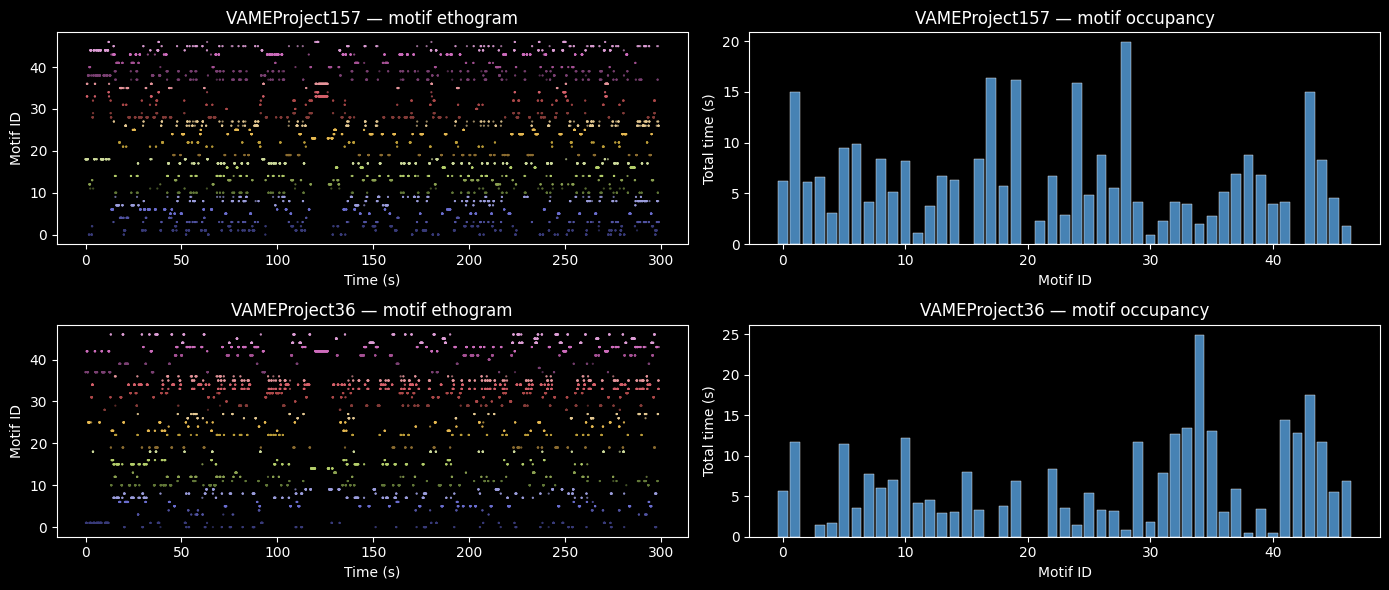

In [23]:
vame_projects = {k: v for k, v in behavior1.data_interfaces.items() if type(v).__name__ == "VAMEProject"}

for key, project in vame_projects.items():
    ms = project.motif_series
    labels = np.array(ms.data[:])
    print(f"{key}:")
    print(f"  MotifSeries name:       {ms.name}")
    print(f"  Shape:                  {labels.shape}  ({labels.shape[0] / ms.rate:.1f} s at {ms.rate} Hz)")
    print(f"  Unique motifs:          {len(np.unique(labels))}  (labels {labels.min()}–{labels.max()})")
    print(f"  Pose estimation linked: {project.pose_estimation is not None}")
    print()

fig, axes = plt.subplots(len(vame_projects), 2, figsize=(14, 3 * len(vame_projects)))

for row_axes, (key, project) in zip(axes, vame_projects.items()):
    ms = project.motif_series
    labels = np.array(ms.data[:])
    time_s = np.arange(len(labels)) / ms.rate

    ax_eth, ax_bar = row_axes
    ax_eth.scatter(time_s, labels, s=0.3, c=labels, cmap="tab20b", alpha=0.7)
    ax_eth.set_xlabel("Time (s)")
    ax_eth.set_ylabel("Motif ID")
    ax_eth.set_title(f"{key} — motif ethogram")

    unique, counts = np.unique(labels, return_counts=True)
    ax_bar.bar(unique, counts / ms.rate, color="steelblue", edgecolor="white", linewidth=0.3)
    ax_bar.set_xlabel("Motif ID")
    ax_bar.set_ylabel("Total time (s)")
    ax_bar.set_title(f"{key} — motif occupancy")

plt.tight_layout()
plt.show()

## Example 2: Fiber photometry + kinematics session

This session (sub-776770, WT, `dLight_dStr` group, `oft_fp` sub-experiment) has simultaneous
fiber photometry recording (dLight1.3b sensor, fiber implanted in the dorsal caudoputamen)
alongside pose estimation and derived kinematics.

In [24]:
nwb_path_fp = "../../../nwb_output/open_field_test/sub-776770/sub-776770_ses-oft-2024-04-11T08-38-14.nwb"

io2 = NWBHDF5IO(nwb_path_fp, mode="r")
nwbfile2 = io2.read()

print(f"Session ID:    {nwbfile2.session_id}")
print(f"Session start: {nwbfile2.session_start_time}")
print(f"Subject ID:    {nwbfile2.subject.subject_id}")
print(f"Genotype:      {nwbfile2.subject.genotype}")
print(f"Sex:           {nwbfile2.subject.sex}")
print(f"Institution:   {nwbfile2.institution}")
print(f"Lab:           {nwbfile2.lab}")

Session ID:    oft-2024-04-11T08-38-14
Session start: 2024-04-11 08:38:14+02:00
Subject ID:    776770
Genotype:      WT
Sex:           U
Institution:   Karolinska Institutet
Lab:           Meletis


### 2.1 Fiber photometry

Fiber photometry recorded dopamine/calcium dynamics in `oft_fp` sessions (31 of 161).
Three signals are stored per session:

- **`processing/ophys/FiberPhotometrySeriesDfOverF`** (~60 Hz) — isosbestic-corrected dF/F (470 nm − scaled 405 nm reference)
- **`acquisition/FiberPhotometrySeriesRawSignal`** (~60 Hz) — raw 470 nm fluorescence (dopamine-sensitive)
- **`acquisition/FiberPhotometrySeriesIsosbesticControl`** (~60 Hz) — raw 405 nm isosbestic reference (motion/photobleaching control)

| Group | Location | Indicator | Fiber insertion |
|-------|----------|-----------|-----------------|
| `dLight_dStr` | Dorsal caudoputamen | dLight1.3b | dCP (AP +0.74, ML ±1.5, DV −2.2) |
| `dLight_vStr` | Central caudoputamen | dLight1.3b | cCP (AP +0.38, ML +2.0, DV −2.9) |
| `fp_dat` / `dat-cre` | Dorsal caudoputamen | jGCaMP8m | dCP |
| `fp_anxa1` / `anxa1-flp` | Dorsal caudoputamen | jGCaMP8m | dCP |

**Note:** Timestamps start at ~5–8 s due to system warm-up. Video and FP clocks are
synchronized by Bonsai at session start.

In [25]:
fp = nwbfile2.processing["ophys"]["FiberPhotometrySeriesDfOverF"]
signal = fp.data[:]
timestamps = fp.timestamps[:]

print(f"Description: {fp.description}")
print(f"Unit: {fp.unit}")
print(f"Data shape: {signal.shape}")
print(f"Time range: {timestamps[0]:.2f} – {timestamps[-1]:.2f} s")
print(f"Sampling rate: ~{1 / np.median(np.diff(timestamps)):.1f} Hz")

fp_meta = nwbfile2.lab_meta_data["fiber_photometry"]
fp_table = fp_meta.fiber_photometry_table
print(f"\nRecording location:    {fp_table['location'][0]}")
print(f"Excitation wavelength: {fp_table['excitation_wavelength_in_nm'][0]} nm")
print(f"Emission wavelength:   {fp_table['emission_wavelength_in_nm'][0]} nm")

Description: Isosbestic-corrected dF/F fiber photometry signal for indicator dLight1.3b. Preprocessing in DoricStudio V5: raw 470 nm and 405 nm fluorescence traces were baseline-normalized (dF/F) and low-pass filtered (10 Hz cutoff); the normalized 405 nm isosbestic trace was then scaled to the 470 nm baseline and subtracted to remove shared artifacts (motion, photobleaching). Acquired via interleaved 470/405 nm LED excitation at ~60 Hz. Corrected dF/F traces were aligned to behavioral events (VAME motif onsets) for downstream peri-event analyses. Original signal column: ("sig" 755.58125_Df * 1) - ("ref" 537.34375_Df * 1).
Unit: a.u.
Data shape: (75731,)
Time range: 6.85 – 1269.02 s
Sampling rate: ~60.0 Hz

Recording location:    Dorsal caudoputamen
Excitation wavelength: 470.0 nm
Emission wavelength:   525.0 nm


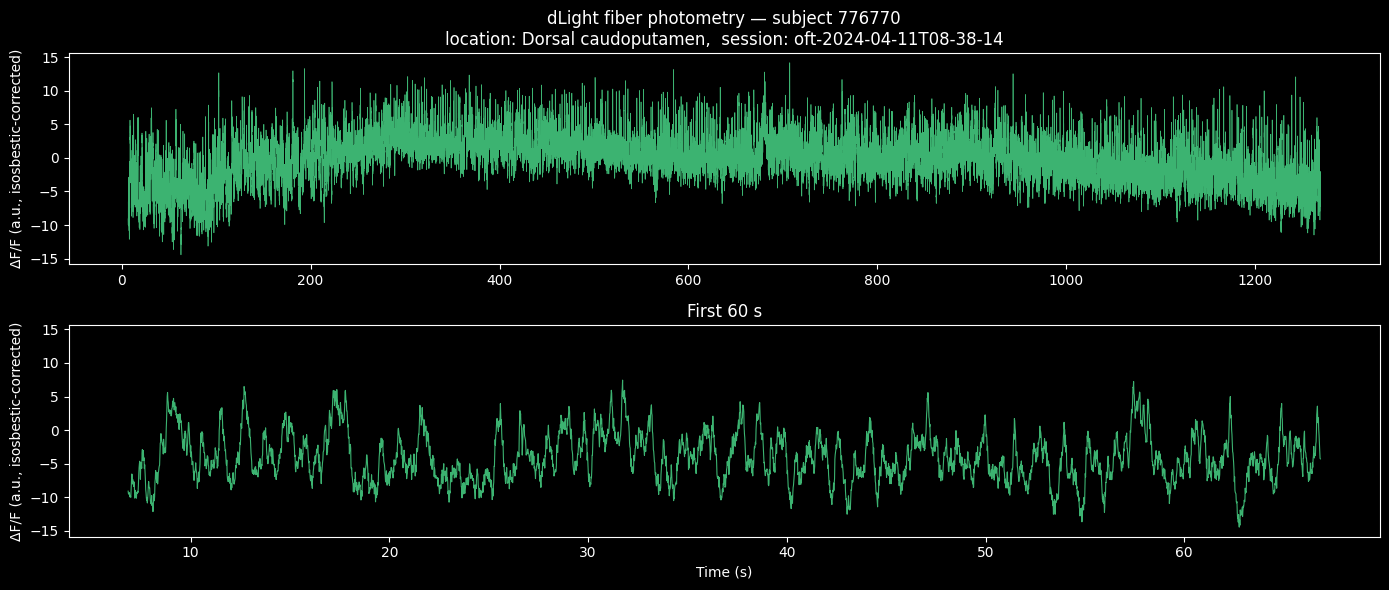

In [26]:
fp_table = nwbfile2.lab_meta_data["fiber_photometry"].fiber_photometry_table

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharey=True)

axes[0].plot(timestamps, signal, linewidth=0.5, color="mediumseagreen")
axes[0].set_ylabel("ΔF/F (a.u., isosbestic-corrected)")
axes[0].set_title(
    f"dLight fiber photometry — subject {nwbfile2.subject.subject_id}\n"
    f"location: {fp_table['location'][0]},  session: {nwbfile2.session_id}"
)

t_end = min(timestamps[0] + 60, timestamps[-1])
mask = timestamps <= t_end
axes[1].plot(timestamps[mask], signal[mask], linewidth=0.8, color="mediumseagreen")
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("ΔF/F (a.u., isosbestic-corrected)")
axes[1].set_title("First 60 s")

plt.tight_layout()
plt.show()

#### Raw acquisition traces (470 nm signal + 405 nm isosbestic)

The raw fluorescence traces output directly by DoricStudio V5 are stored in `acquisition/`:

- **`FiberPhotometrySeriesRawSignal`** — 470 nm excitation, dopamine-sensitive dLight1.3b fluorescence
- **`FiberPhotometrySeriesIsosbesticControl`** — 405 nm isosbestic excitation, insensitive to dopamine;
  used as a motion artifact and photobleaching control

Both channels share the same sampling rate (~60 Hz) and starting time. The isosbestic-corrected
dF/F in `processing/ophys/` is derived from these two channels (470 nm − scaled 405 nm reference fit).

Signal (470 nm):    (75759,),  range [313.67, 756.40] a.u.
Reference (405 nm): (75759,),  range [214.16, 552.38] a.u.
Time range:         6.83 – 1269.47 s


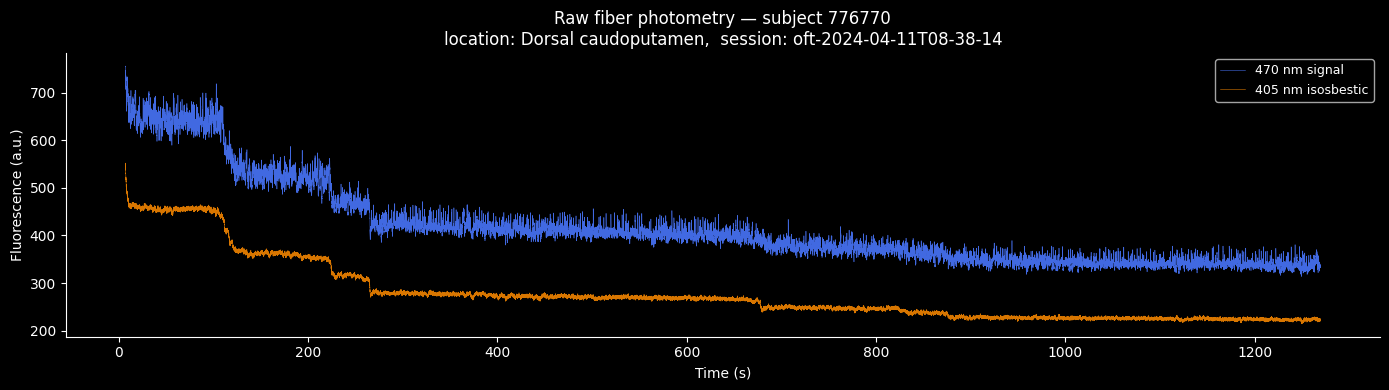

In [27]:
raw_sig = nwbfile2.acquisition["FiberPhotometrySeriesRawSignal"]
raw_ref = nwbfile2.acquisition["FiberPhotometrySeriesIsosbesticControl"]

sig_data = raw_sig.data[:]
ref_data = raw_ref.data[:]
raw_time = raw_sig.get_timestamps()

print(f"Signal (470 nm):    {sig_data.shape},  range [{sig_data.min():.2f}, {sig_data.max():.2f}] a.u.")
print(f"Reference (405 nm): {ref_data.shape},  range [{ref_data.min():.2f}, {ref_data.max():.2f}] a.u.")
print(f"Time range:         {raw_time[0]:.2f} – {raw_time[-1]:.2f} s")

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(raw_time, sig_data, linewidth=0.4, color="royalblue", label="470 nm signal")
ax.plot(raw_time, ref_data, linewidth=0.4, color="darkorange", alpha=0.85, label="405 nm isosbestic")
ax.set_ylabel("Fluorescence (a.u.)")
ax.set_xlabel("Time (s)")
ax.set_title(
    f"Raw fiber photometry — subject {nwbfile2.subject.subject_id}\n"
    f"location: {fp_table['location'][0]},  session: {nwbfile2.session_id}"
)
ax.legend(fontsize=9)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

### 2.2 Kinematics

Derived kinematics computed from the pose estimation data, stored in
`processing/behavior/Kinematics` as a `BehavioralTimeSeries` container at 30 Hz.

| Time series | Unit | Description |
|-------------|------|-------------|
| `linear_velocity` | m/s | Movement speed of the body center |
| `linear_acceleration` | m/s² | Movement acceleration of the body center |
| `angular_velocity` | rad/s | Angular speed of body orientation |
| `distance_moved` | m | Distance moved by the body center per frame |
| `angular_distance` | rad | Angular distance of body orientation change per frame |
| `linear_velocity_snout` | m/s | Movement speed of the snout |
| `distance_moved_snout` | m | Distance moved by the snout per frame |

In [28]:
behavior2 = nwbfile2.processing["behavior"]
kinematics = behavior2["Kinematics"]

print("Available kinematics time series:")
for name, ts in kinematics.time_series.items():
    data = ts.data[:]
    print(f"  {name:25s}  shape={str(data.shape):12s}  unit={ts.unit:12s}  range=[{data.min():.2f}, {data.max():.2f}]")

Available kinematics time series:
  angular_distance           shape=(38125,)      unit=rad           range=[nan, nan]
  angular_velocity           shape=(38125,)      unit=rad/s         range=[nan, nan]
  distance_moved             shape=(38125,)      unit=m             range=[nan, nan]
  distance_moved_snout       shape=(38125,)      unit=m             range=[nan, nan]
  linear_acceleration        shape=(38125,)      unit=m/s^2         range=[nan, nan]
  linear_velocity            shape=(38125,)      unit=m/s           range=[nan, nan]
  linear_velocity_snout      shape=(38125,)      unit=m/s           range=[nan, nan]


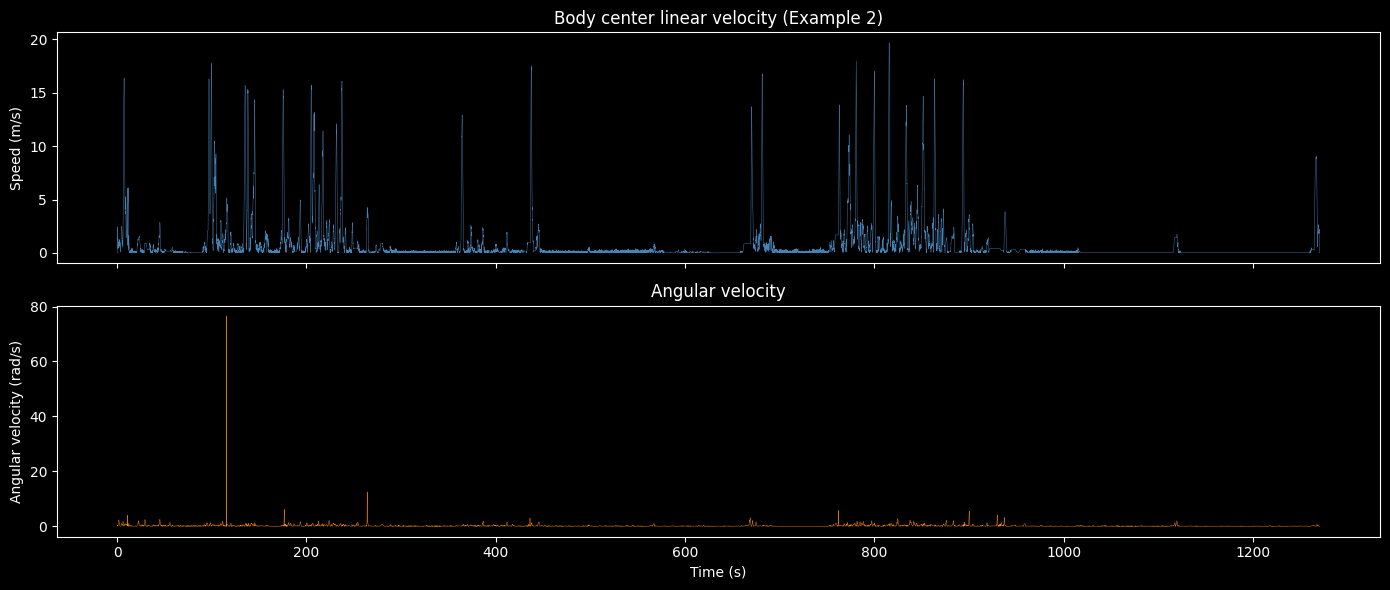

In [29]:
speed = kinematics.time_series["linear_velocity"]
speed_data = speed.data[:]
speed_time = np.arange(len(speed_data)) / speed.rate

angular_speed = kinematics.time_series["angular_velocity"]
angular_data = angular_speed.data[:]

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

axes[0].plot(speed_time, speed_data, linewidth=0.3, color="steelblue")
axes[0].set_ylabel(f"Speed ({speed.unit})")
axes[0].set_title("Body center linear velocity (Example 2)")

axes[1].plot(speed_time, angular_data, linewidth=0.3, color="darkorange")
axes[1].set_ylabel(f"Angular velocity ({angular_speed.unit})")
axes[1].set_xlabel("Time (s)")
axes[1].set_title("Angular velocity")

plt.tight_layout()
plt.show()

### 2.3 Combined dF/F and velocity trace

Both signals share the same time reference (synchronized by Bonsai at session start).
The dF/F signal is globally z-scored for display; velocity is plotted in the native unit
stored in the NWB file. FP timestamps begin at ~7 s due to system warm-up.

The zoomed panel (bottom row) shows a 60-second representative window to make the
sub-second co-modulation visible.

/var/folders/vv/cv45rgsd39z2bm7hjhh65xm80000gn/T/ipykernel_27994/233760750.py:44: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


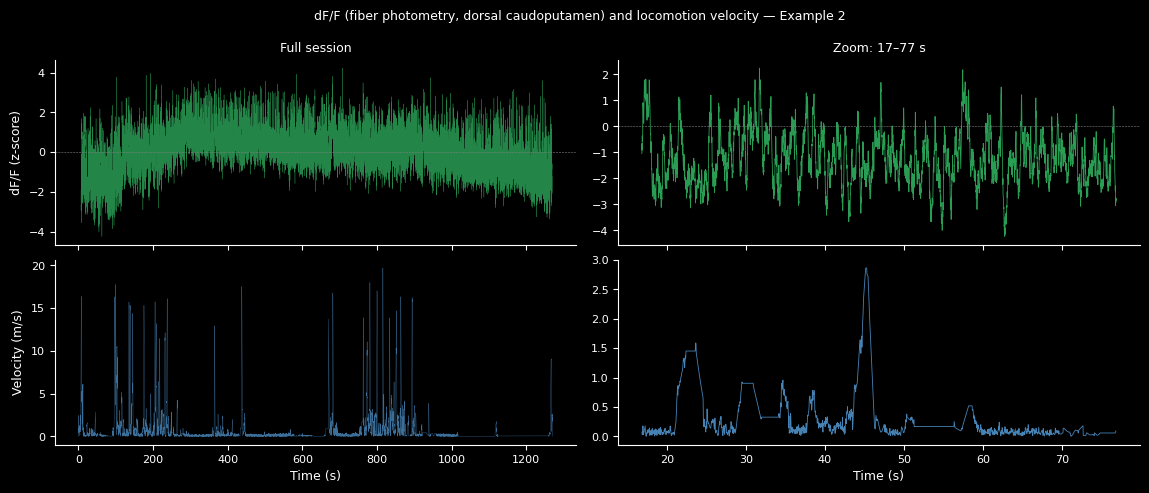

In [30]:
# Z-score dF/F for display
signal_z = (signal - signal.mean()) / signal.std()

# Choose a 60-second zoom window starting where FP is stable
_t0_zoom = float(timestamps[0]) + 10.0
_t1_zoom = _t0_zoom + 60.0

fig_comb, axes_comb = plt.subplots(
    2, 2,
    figsize=(14, 5),
    sharex="col",
    gridspec_kw={"wspace": 0.08, "hspace": 0.08},
)

# ---------- full session (left column) ----------
axes_comb[0, 0].plot(timestamps, signal_z, linewidth=0.25, color="#2a9d54", alpha=0.85)
axes_comb[0, 0].set_ylabel("dF/F (z-score)", fontsize=9)
axes_comb[0, 0].set_title("Full session", fontsize=9)
axes_comb[0, 0].axhline(0, color="gray", linewidth=0.4, linestyle="--")

axes_comb[1, 0].plot(speed_time, speed_data, linewidth=0.25, color="steelblue", alpha=0.85)
axes_comb[1, 0].set_ylabel(f"Velocity ({speed.unit})", fontsize=9)
axes_comb[1, 0].set_xlabel("Time (s)", fontsize=9)

# ---------- 60-second zoom (right column) ----------
_fp_mask = (timestamps >= _t0_zoom) & (timestamps <= _t1_zoom)
_vel_mask = (speed_time >= _t0_zoom) & (speed_time <= _t1_zoom)

axes_comb[0, 1].plot(timestamps[_fp_mask], signal_z[_fp_mask], linewidth=0.6, color="#2a9d54")
axes_comb[0, 1].axhline(0, color="gray", linewidth=0.4, linestyle="--")
axes_comb[0, 1].set_title(f"Zoom: {_t0_zoom:.0f}–{_t1_zoom:.0f} s", fontsize=9)

axes_comb[1, 1].plot(speed_time[_vel_mask], speed_data[_vel_mask], linewidth=0.6, color="steelblue")
axes_comb[1, 1].set_xlabel("Time (s)", fontsize=9)

for ax in axes_comb.flat:
    ax.spines[["top", "right"]].set_visible(False)
    ax.tick_params(labelsize=8)

fig_comb.suptitle(
    "dF/F (fiber photometry, dorsal caudoputamen) and locomotion velocity — Example 2",
    fontsize=9,
)
plt.tight_layout()
plt.show()


## NWB file structure overview

Summary of all containers in both example files.

In [31]:
for label, nwbfile in [("Example 1 — VAME", nwbfile1), ("Example 2 — FP + Kinematics", nwbfile2)]:
    print(f"\n{'='*55}")
    print(f"  {label}")
    print(f"{'='*55}")
    print("Acquisition:")
    for name, obj in nwbfile.acquisition.items():
        print(f"  {name}: {type(obj).__name__}")
    print("\nProcessing:")
    for mod_name, module in nwbfile.processing.items():
        print(f"  {mod_name}/")
        for name, obj in module.data_interfaces.items():
            print(f"    {name}: {type(obj).__name__}")
    print("\nDevices:")
    for name in nwbfile.devices:
        print(f"  {name}")
    if nwbfile.lab_meta_data:
        print("\nLab metadata:")
        for name in nwbfile.lab_meta_data:
            print(f"  {name}")


  Example 1 — VAME
Acquisition:
  Video oft_2023-05-16T15_31_06: ImageSeries

Processing:
  behavior/
    Kinematics: BehavioralTimeSeries
    PoseEstimationDeepLabCut: PoseEstimation
    Skeletons: Skeletons
    VAMEProject157: VAMEProject
    VAMEProject36: VAMEProject

Devices:
  Oryx 10GigE Camera

  Example 2 — FP + Kinematics
Acquisition:
  FiberPhotometrySeriesIsosbesticControl: FiberPhotometryResponseSeries
  FiberPhotometrySeriesRawSignal: FiberPhotometryResponseSeries
  Video oft_2024-04-11T08_38_14: ImageSeries

Processing:
  behavior/
    Kinematics: BehavioralTimeSeries
    PoseEstimationDeepLabCut: PoseEstimation
    Skeletons: Skeletons
    VAMEProject157: VAMEProject
  ophys/
    FiberPhotometrySeriesDfOverF: FiberPhotometryResponseSeries

Devices:
  Oryx 10GigE Camera
  excitation_source_isosbestic
  excitation_source_signal
  optical_fiber_cpu
  photodetector

Lab metadata:
  fiber_photometry


In [32]:
io1.close()
io2.close()